# 16 · Time Series Analysis

**Difficulty:** Intermediate-Advanced | **Time:** ~3 hours

Time series data is everywhere: stock prices, weather, sales, sensor readings.

## Table of Contents
1. Time Series Components
2. Trend, Seasonality & Noise
3. Stationarity & Transformations
4. Autocorrelation (ACF/PACF)
5. Moving Averages & Smoothing
6. ARIMA Model
7. ML for Time Series (features)
8. Real-World: Stock Price Forecasting

## 1. Time Series Components

Every time series = **Trend + Seasonality + Residual**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

# Generate realistic time series: monthly retail sales
np.random.seed(42)
periods = 5 * 12  # 5 years monthly
dates = pd.date_range('2019-01', periods=periods, freq='MS')

t = np.arange(periods)
trend      = 50000 + 1200 * t                             # upward trend
seasonality = 15000 * np.sin(2*np.pi*t/12 - np.pi/2)    # annual cycle
noise       = np.random.normal(0, 5000, periods)          # random noise
sales       = trend + seasonality + noise

ts = pd.Series(sales, index=dates, name='Monthly Sales')
print('Time series created:')
print(ts.head(12))
print(f'\nShape: {ts.shape}, Range: {ts.min():.0f} - {ts.max():.0f}')

Time series created:
2019-01-01    37483.570765
2019-02-01    37518.297437
2019-03-01    48138.442691
2019-04-01    61215.149282
2019-05-01    61129.233126
2019-06-01    67819.696272
2019-07-01    80096.064078
2019-08-01    75227.554703
2019-09-01    64752.628070
2019-10-01    63512.800218
2019-11-01    52182.911536
2019-12-01    47880.970175
Freq: MS, Name: Monthly Sales, dtype: float64

Shape: (60,), Range: 37484 - 134955


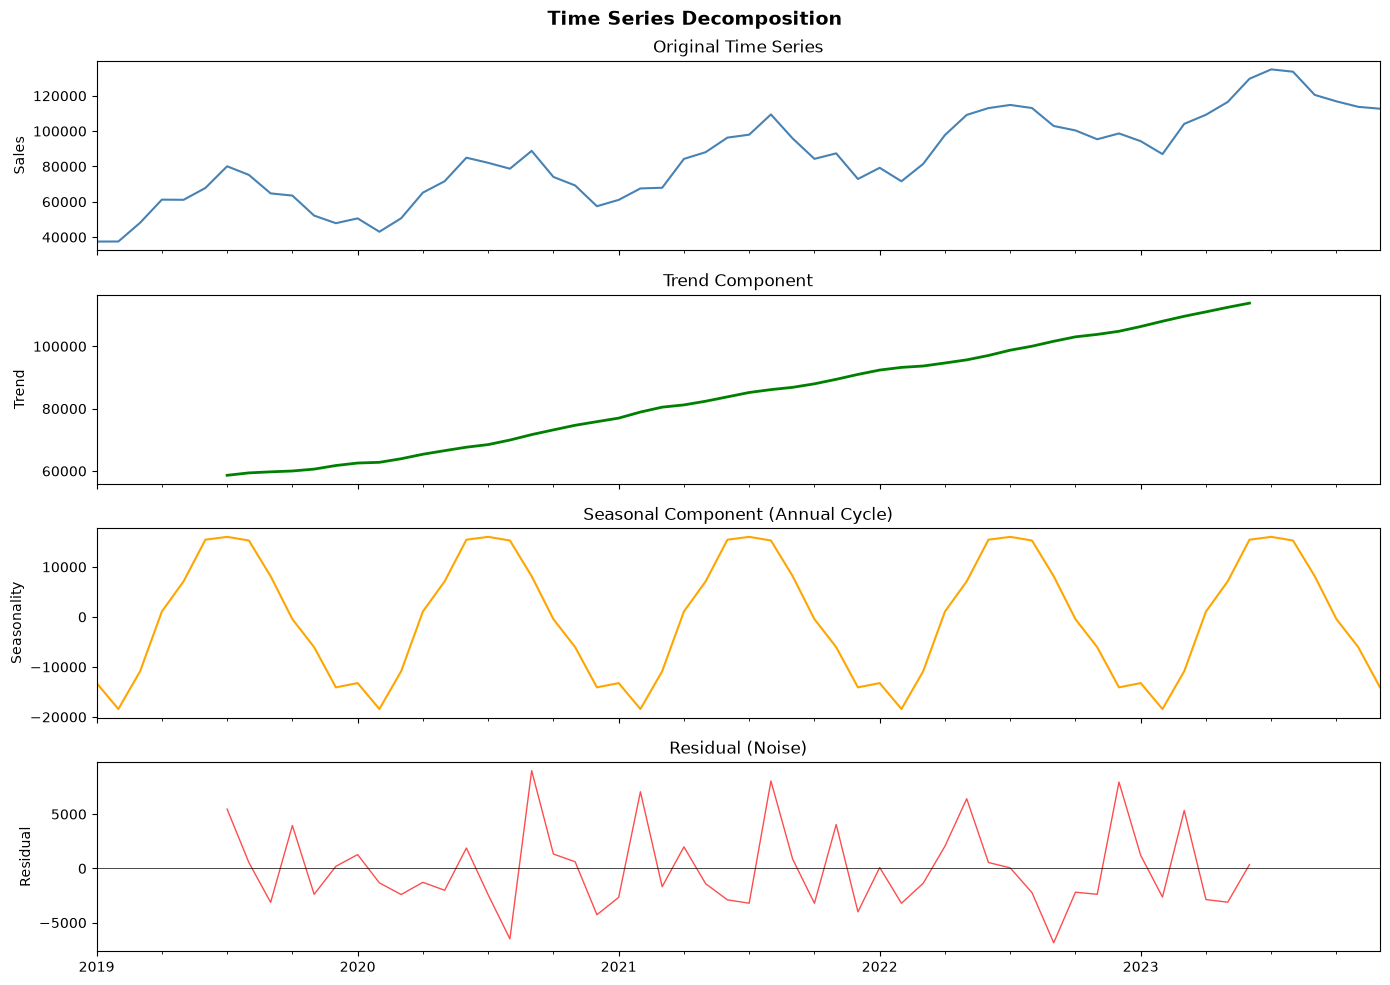

In [2]:
# Decompose into components
result = seasonal_decompose(ts, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

ts.plot(ax=axes[0], color='steelblue', linewidth=1.5)
axes[0].set_title('Original Time Series'); axes[0].set_ylabel('Sales')

result.trend.plot(ax=axes[1], color='green', linewidth=2)
axes[1].set_title('Trend Component'); axes[1].set_ylabel('Trend')

result.seasonal.plot(ax=axes[2], color='orange', linewidth=1.5)
axes[2].set_title('Seasonal Component (Annual Cycle)'); axes[2].set_ylabel('Seasonality')

result.resid.plot(ax=axes[3], color='red', linewidth=1, alpha=0.7)
axes[3].axhline(0, color='black', lw=0.5)
axes[3].set_title('Residual (Noise)'); axes[3].set_ylabel('Residual')

plt.suptitle('Time Series Decomposition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/tmp/ts_decompose.png', dpi=100)
plt.show()

## 2. Stationarity — Critical for Time Series Models

Original series:
  ADF Statistic: 1.1937
  p-value:       0.9959
  -> NON-STATIONARY (needs differencing)

After 1st differencing:
  ADF Statistic: -7.2463
  p-value:       0.0000
  -> STATIONARY (good for ARIMA)


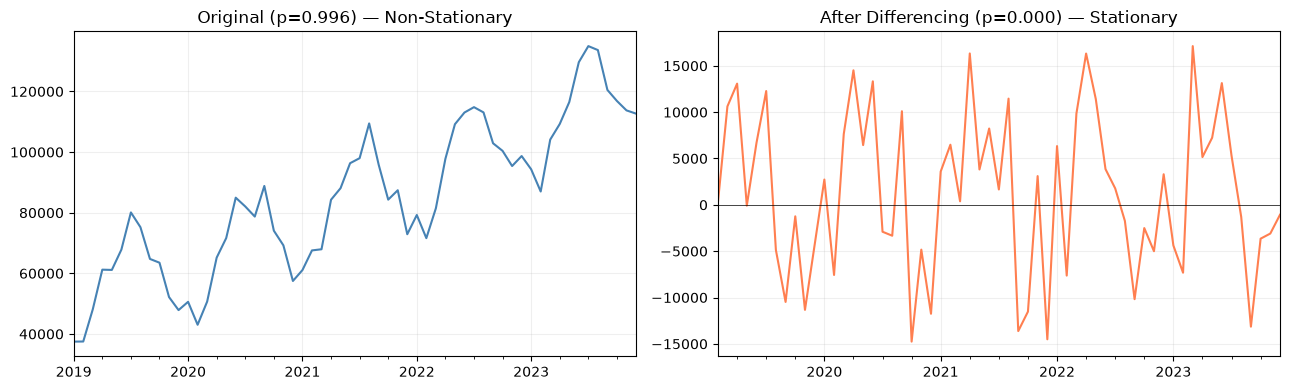

In [3]:
def adf_test(series):
    result = adfuller(series.dropna())
    print(f'  ADF Statistic: {result[0]:.4f}')
    print(f'  p-value:       {result[1]:.4f}')
    if result[1] < 0.05:
        print('  -> STATIONARY (good for ARIMA)')
    else:
        print('  -> NON-STATIONARY (needs differencing)')
    return result[1]

print('Original series:')
p_orig = adf_test(ts)

print('\nAfter 1st differencing:')
ts_diff = ts.diff().dropna()
p_diff = adf_test(ts_diff)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ts.plot(ax=axes[0], color='steelblue')
axes[0].set_title(f'Original (p={p_orig:.3f}) — Non-Stationary')
ts_diff.plot(ax=axes[1], color='coral')
axes[1].set_title(f'After Differencing (p={p_diff:.3f}) — Stationary')
axes[1].axhline(0, color='black', lw=0.5)
for ax in axes: ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('/tmp/stationarity.png', dpi=100)
plt.show()

## 3. Autocorrelation — ACF & PACF

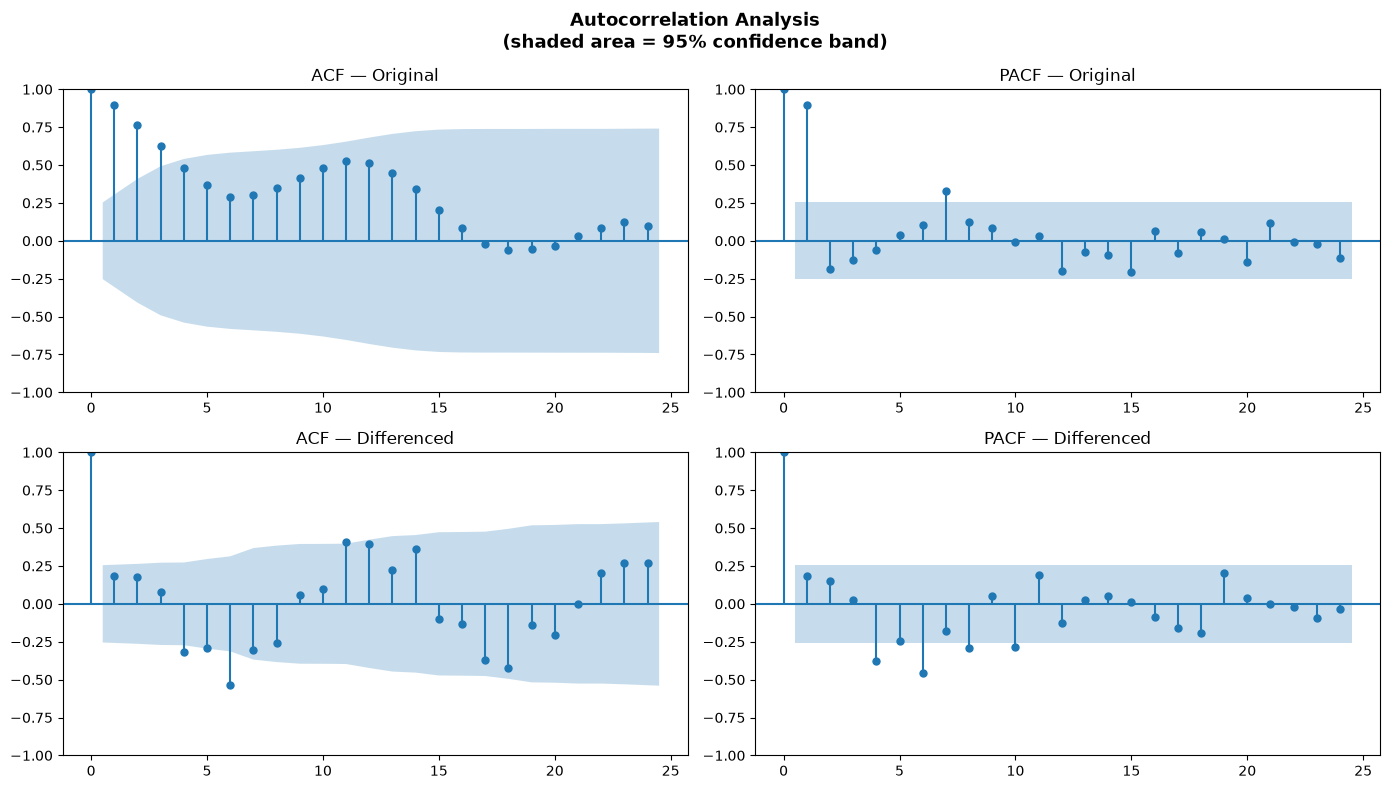

Reading ACF/PACF:
  ACF: how correlated series is with its own lagged values
  PACF: direct correlation at lag k (controlling for shorter lags)
  Spikes at lag 12 => annual seasonality
  p (AR order) = PACF cut-off lag
  q (MA order) = ACF cut-off lag


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(ts, ax=axes[0,0], lags=24, title='ACF — Original')
plot_pacf(ts, ax=axes[0,1], lags=24, method='ywm', title='PACF — Original')
plot_acf(ts_diff, ax=axes[1,0], lags=24, title='ACF — Differenced')
plot_pacf(ts_diff, ax=axes[1,1], lags=24, method='ywm', title='PACF — Differenced')

plt.suptitle('Autocorrelation Analysis\n(shaded area = 95% confidence band)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/tmp/acf_pacf.png', dpi=100)
plt.show()

print('Reading ACF/PACF:')
print('  ACF: how correlated series is with its own lagged values')
print('  PACF: direct correlation at lag k (controlling for shorter lags)')
print('  Spikes at lag 12 => annual seasonality')
print('  p (AR order) = PACF cut-off lag')
print('  q (MA order) = ACF cut-off lag')

## 4. Moving Averages & Smoothing

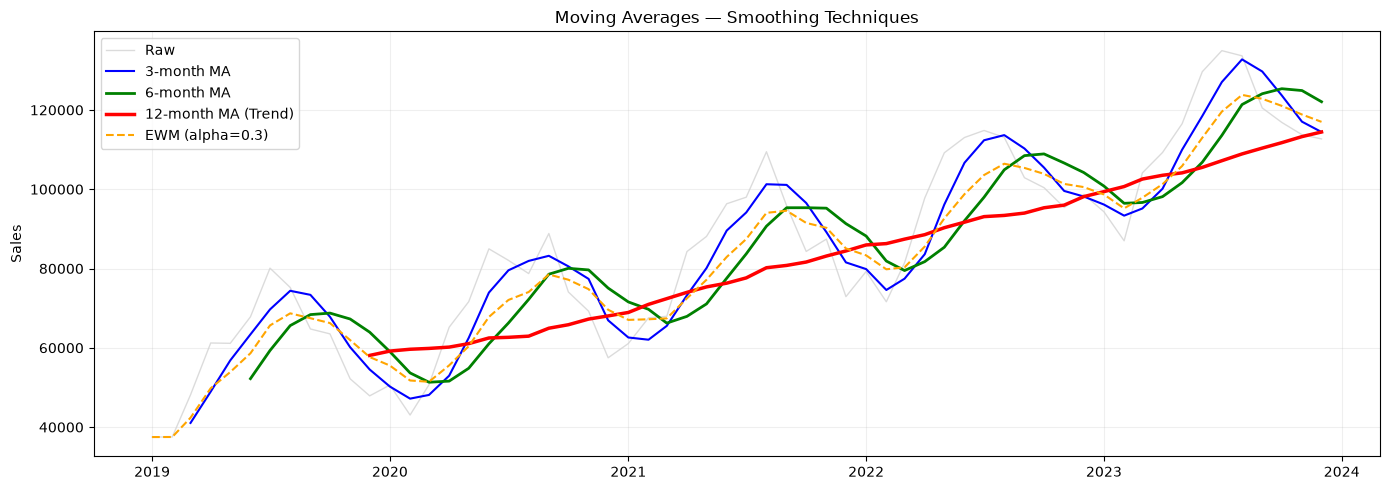

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(ts, color='lightgray', linewidth=1, label='Raw', alpha=0.8)
ax.plot(ts.rolling(3).mean(),   color='blue',  linewidth=1.5, label='3-month MA')
ax.plot(ts.rolling(6).mean(),   color='green', linewidth=2,   label='6-month MA')
ax.plot(ts.rolling(12).mean(),  color='red',   linewidth=2.5, label='12-month MA (Trend)')
ax.plot(ts.ewm(alpha=0.3).mean(), color='orange', linewidth=1.5, linestyle='--', label='EWM (alpha=0.3)')

ax.set_title('Moving Averages — Smoothing Techniques')
ax.set_ylabel('Sales'); ax.legend(); ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('/tmp/moving_averages.png', dpi=100)
plt.show()

## 5. ARIMA Model

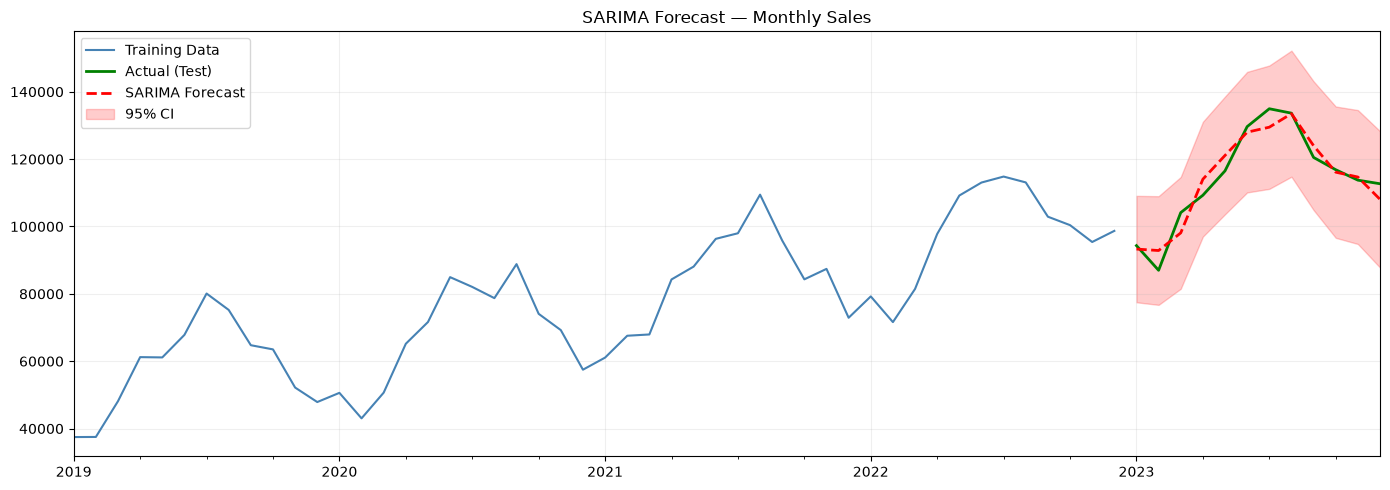

MAPE: 2.98%


In [6]:
from statsmodels.tsa.arima.model import ARIMA

# Split: last 12 months = test
train_ts = ts[:-12]
test_ts  = ts[-12:]

# Fit ARIMA(1,1,1)(1,1,1)[12] — with seasonal component
try:
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    model = SARIMAX(train_ts, order=(1,1,1), seasonal_order=(1,1,1,12),
                    enforce_stationarity=False, enforce_invertibility=False)
    results = model.fit(disp=False)
    
    forecast = results.forecast(steps=12)
    conf_int = results.get_forecast(steps=12).conf_int()
    
    fig, ax = plt.subplots(figsize=(14, 5))
    train_ts.plot(ax=ax, color='steelblue', label='Training Data')
    test_ts.plot(ax=ax, color='green', linewidth=2, label='Actual (Test)')
    forecast.plot(ax=ax, color='red', linewidth=2, linestyle='--', label='SARIMA Forecast')
    ax.fill_between(conf_int.index, conf_int.iloc[:,0], conf_int.iloc[:,1],
                     alpha=0.2, color='red', label='95% CI')
    ax.set_title('SARIMA Forecast — Monthly Sales')
    ax.legend(); ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig('/tmp/arima_forecast.png', dpi=100)
    plt.show()
    
    from sklearn.metrics import mean_absolute_percentage_error
    mape = mean_absolute_percentage_error(test_ts, forecast) * 100
    print(f'MAPE: {mape:.2f}%')
except Exception as e:
    print(f'SARIMA error: {e}')
    print('Falling back to simple ARIMA...')
    model = ARIMA(train_ts, order=(1,1,1))
    res = model.fit()
    fc = res.forecast(steps=12)
    print(f'ARIMA forecast (first 3): {fc[:3].values.round(0)}')
    print(f'Actual (first 3):         {test_ts[:3].values.round(0)}')

## 6. ML for Time Series — Feature Engineering

In [7]:
# Convert time series to supervised ML problem using lag features
def create_lag_features(series, n_lags=12):
    df = pd.DataFrame({'y': series})
    for lag in range(1, n_lags+1):
        df[f'lag_{lag}'] = series.shift(lag)
    # Calendar features
    df['month']      = series.index.month
    df['quarter']    = series.index.quarter
    df['is_q4']      = (series.index.quarter == 4).astype(int)
    df['trend']      = range(len(series))
    return df.dropna()

df_lag = create_lag_features(ts, n_lags=12)
print(f'Feature matrix: {df_lag.shape}')
print(df_lag.head())

X_ts = df_lag.drop('y', axis=1)
y_ts = df_lag['y']

# Time-aware split (no shuffling!)
split = int(len(X_ts) * 0.8)
X_tr_ts, X_te_ts = X_ts.iloc[:split], X_ts.iloc[split:]
y_tr_ts, y_te_ts = y_ts.iloc[:split], y_ts.iloc[split:]

Feature matrix: (48, 17)
                       y         lag_1         lag_2         lag_3  \
2020-01-01  50609.811358  47880.970175  52182.911536  63512.800218   
2020-02-01  43043.217720  50609.811358  47880.970175  52182.911536   
2020-03-01  50675.410837  43043.217720  50609.811358  47880.970175   
2020-04-01  65188.562354  50675.410837  43043.217720  50609.811358   
2020-05-01  71635.844398  65188.562354  50675.410837  43043.217720   

                   lag_4         lag_5         lag_6         lag_7  \
2020-01-01  64752.628070  75227.554703  80096.064078  67819.696272   
2020-02-01  63512.800218  64752.628070  75227.554703  80096.064078   
2020-03-01  52182.911536  63512.800218  64752.628070  75227.554703   
2020-04-01  47880.970175  52182.911536  63512.800218  64752.628070   
2020-05-01  50609.811358  47880.970175  52182.911536  63512.800218   

                   lag_8         lag_9        lag_10        lag_11  \
2020-01-01  61129.233126  61215.149282  48138.442691  37518.297

Random Forest MAPE: 7.00%


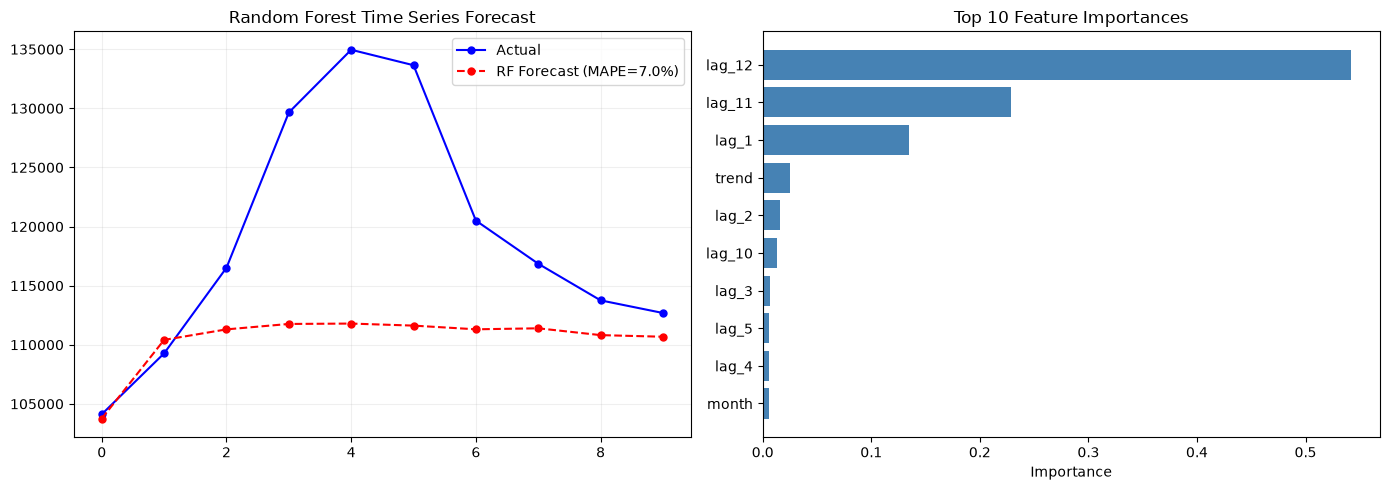

In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error

rf_ts = RandomForestRegressor(n_estimators=200, random_state=42)
rf_ts.fit(X_tr_ts, y_tr_ts)
y_pred_ts = rf_ts.predict(X_te_ts)

mape = mean_absolute_percentage_error(y_te_ts, y_pred_ts) * 100
print(f'Random Forest MAPE: {mape:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Forecast vs actual
axes[0].plot(y_te_ts.values, 'b-o', ms=5, label='Actual')
axes[0].plot(y_pred_ts,      'r--o', ms=5, label=f'RF Forecast (MAPE={mape:.1f}%)')
axes[0].set_title('Random Forest Time Series Forecast')
axes[0].legend(); axes[0].grid(alpha=0.2)

# Feature importance
imp = pd.Series(rf_ts.feature_importances_, index=X_ts.columns).sort_values(ascending=True).tail(10)
axes[1].barh(imp.index, imp.values, color='steelblue')
axes[1].set_title('Top 10 Feature Importances')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('/tmp/ts_rf.png', dpi=100)
plt.show()

## Summary

| Method | Use Case |
|---|---|
| Decomposition | Understand trend/seasonality |
| Moving Average | Smooth noise, find trend |
| ARIMA/SARIMA | Statistical forecasting |
| ML + Lag Features | Complex patterns, many features |

**Time Series Rules:**
- Always use time-aware splits (no shuffle!)
- Test data must be FUTURE relative to training
- Lag features are your most powerful tools

**Next notebook →** `17_NLP_Text_Analysis.ipynb`